In [2]:
#@title General Imports

# system tools
import os
import time
import shutil
import subprocess
from pathlib import Path
import tempfile
import zipfile
import warnings
# Mute only this ArviZ FutureWarning message 
# We have pinned corner and emcee versions to avoid this becoming an issue
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"arviz(\.|$)",
    message=r".*ArviZ is undergoing a major refactor.*",
)
# data analysis tools
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display
import pandas as pd
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from scipy.optimize import approx_fprime
import emcee
import corner
import astropy.units as u
from astropy.coordinates import SkyCoord
try:
    from google.colab import sheets  # this will only work if you are running on Colab
except:
    pass

# web scrapping tools
import requests

In [3]:
#@title Cloning the GitHub repository
if not os.path.exists("data-challenge-1"):

    # Clone
    !printf "🐑 " && git clone --depth 1 https://github.com/microlensing-data-challenge/data-challenge-1.git
else:
    print("ℹ️ data-challenge-1 already exists; skipping clone")

if not os.path.exists("data-challenge-1/lc"):
    # Extract with lightweight progress dots every N checkpoints
    print("\n🗃️ Extracting files")
    # extract with progress dots, if supported
    try:
        subprocess.run(["tar", "-xzf", "data-challenge-1/lc.tar.gz", "-C",
                        "data-challenge-1/", "--checkpoint=1000",
                        "--checkpoint-action=dot"], check=True)
    except:
        subprocess.run(["tar", "-xzf", "data-challenge-1/lc.tar.gz",
                        "-C", "data-challenge-1/"], check=True)

print("\n✅ Lightcurve files are ready.")

🐑 Cloning into 'data-challenge-1'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 92.59 MiB | 24.11 MiB/s, done.

🗃️ Extracting files


tar: Option --checkpoint=1000 is not supported
Usage:
  List:    tar -tf <archive-filename>
  Extract: tar -xf <archive-filename>
  Create:  tar -cf <archive-filename> [filenames...]
  Help:    tar --help



✅ Lightcurve files are ready.


In [57]:
master_file = './data-challenge-1/Answers/master_file.txt'
header_file = './data-challenge-1/Answers/wfirstColumnNumbers.txt'

rows = []
with open(master_file, "r") as f:
    for line in f:
        line = line.strip()
        # Skip empty lines or comment lines
        if not line or line.startswith("#"):
            continue

        tokens = line.split()  # split on whitespace
        # Keep only binary-lens events
        if "omcassan" not in tokens:
            continue

        # Single-lens lines should have exactly 96 columns
        if len(tokens) != 82:
            continue
        
        rows.append(tokens)
        
df_bl = pd.DataFrame(rows)

# For binary star lenses and bound planets they are:
# 72 - unimportant
# 73 - Delta chi^2 (relative to a flat line)
# 74 - unimportant
# 75 - Delta chi^2 (relative to a single lens fit PSPL or FSPL if necessary)
# 76 - |
# 77 - unimportant
# 78 - simulated event type (ombin = Binary star, omcassan = Bound planet) 
# 79 - unimportant (I think)
# 80 - lightcurve filename root
# 81 - Data challenge lightcurve number

# make an array of zeros with 82 elements
colnames_82 = np.zeros(82, dtype=object)

# Read the header file
with open(header_file, 'r') as f:
    for i, line in enumerate(f):
        if i >= 82:  # Only read the first 82 lines for the binary lens events
            break
        line = line.strip()
        # Skip empty lines or comments
        if not line or line.startswith('#'):
            continue
        # The second token is the 'name'
        parts = line.split()
        colnames_82[int(parts[0])] = parts[1]
        
# Replace the column names in colnames_82
colnames_82[73] = 'Delta chi2 flat'
colnames_82[75] = 'Delta chi2 single lens'
colnames_82[78] = 'sim type'
colnames_82[80] = 'filename'
colnames_82[81] = 'lc_number'

# Make sure the column names are unique
for i in range(82):
    if colnames_82[i] == '|' or colnames_82[i] == 0:
        colnames_82[i] = 'col_' + str(i)

# Replace the column names in the data_frame
df_bl.columns = colnames_82

# Remove the dummy columns 'col_*'
df_bl = df_bl.loc[:, ~df_bl.columns.str.startswith('col_')]


In [58]:
lc_number_bl = df_bl['lc_number'].to_numpy()
lc_file_path_format = 'data-challenge-1/lc/ulwdc1_XXX_filter.txt'
lc_file_paths_W149_bl = [lc_file_path_format.replace('filter', 'W149')] * len(lc_number_bl)
lc_file_paths_Z087_bl = [lc_file_path_format.replace('filter', 'Z087')] * len(lc_number_bl)
lc_file_paths_W149_bl = [path.replace('XXX', str(num).zfill(3)) for path, num in zip(lc_file_paths_W149_bl, lc_number_bl)]
lc_file_paths_Z087_bl = [path.replace('XXX', str(num).zfill(3)) for path, num in zip(lc_file_paths_Z087_bl, lc_number_bl)]
df_bl['lc_file_path_W149'] = lc_file_paths_W149_bl
df_bl['lc_file_path_Z087'] = lc_file_paths_Z087_bl
df_bl

,idx,subrun,field,l,b,ra,dec,src_id,Ds,Rs,...,Delta chi2 flat,chi2_1,Delta chi2 single lens,normw,sim type,sigma_tE,filename,lc_number,lc_file_path_W149,lc_file_path_Z087
0,2683,4,87,1.21885,-0.937016,268.036,-28.3744,3589,9.675,0.886,...,76240,0,6860.52,|,omcassan,0.613786,omcassan_4_87_2683,4,data-challenge-1/lc/ulwdc1_004_W149.txt,data-challenge-1/lc/ulwdc1_004_Z087.txt
1,262,2,83,1.04324,-2.03775,269.017,-29.0827,3730,9.003,0.688,...,380416,0,383.459,|,omcassan,0.338728,omcassan_2_83_262,8,data-challenge-1/lc/ulwdc1_008_W149.txt,data-challenge-1/lc/ulwdc1_008_Z087.txt
2,657,3,32,0.133009,-1.76616,268.221,-29.7307,3803,9.215,1.225,...,4.23893e+07,0,5681.29,|,omcassan,0.404041,omcassan_3_32_657,12,data-challenge-1/lc/ulwdc1_012_W149.txt,data-challenge-1/lc/ulwdc1_012_Z087.txt
3,623,0,8,-0.451107,-1.23271,267.348,-29.9601,7265,6.968,0.254,...,357404,0,2515.19,|,omcassan,0.105428,omcassan_0_8_623,25,data-challenge-1/lc/ulwdc1_025_W149.txt,data-challenge-1/lc/ulwdc1_025_Z087.txt
4,1050,4,109,1.52853,-1.95811,269.216,-28.6232,4041,10.026,3.866,...,1.64356e+08,0,1218.02,|,omcassan,0.520323,omcassan_4_109_1050,32,data-challenge-1/lc/ulwdc1_032_W149.txt,data-challenge-1/lc/ulwdc1_032_Z087.txt
5,833,3,88,1.11824,-0.668013,267.715,-28.3235,2281,8.093,0.861,...,955694,0,2718.51,|,omcassan,0.486863,omcassan_3_88_833,40,data-challenge-1/lc/ulwdc1_040_W149.txt,data-challenge-1/lc/ulwdc1_040_Z087.txt
6,3146,4,18,-0.106723,-1.98473,268.298,-30.0481,3893,9.267,0.822,...,4.27037e+07,1,274.562,|,omcassan,0.540434,omcassan_4_18_3146,47,data-challenge-1/lc/ulwdc1_047_W149.txt,data-challenge-1/lc/ulwdc1_047_Z087.txt
7,1873,2,34,0.0925122,-1.07923,267.518,-29.415,2979,8.895,0.822,...,241875,0,309.11,|,omcassan,0.294777,omcassan_2_34_1873,50,data-challenge-1/lc/ulwdc1_050_W149.txt,data-challenge-1/lc/ulwdc1_050_Z087.txt
8,537,5,75,0.760366,-0.61572,267.455,-28.6039,15118,9.152,0.639,...,10863.4,0,364.734,|,omcassan,0.749276,omcassan_5_75_537,53,data-challenge-1/lc/ulwdc1_053_W149.txt,data-challenge-1/lc/ulwdc1_053_Z087.txt
9,2947,3,9,-0.460921,-1.05033,267.162,-29.8747,18483,10.269,0.321,...,54087.3,0,1769.82,|,omcassan,0.495614,omcassan_3_9_2947,62,data-challenge-1/lc/ulwdc1_062_W149.txt,data-challenge-1/lc/ulwdc1_062_Z087.txt


In [59]:
header = ["Event_name",
          "Event_number",
          "RA_(deg)",
          "Dec_(deg)",
          "Distance",
          "A_W149",
          "sigma_A_W149",
          "A_Z087",
          "sigma_A_Z087"
]
event_info_bl = pd.read_csv('./data-challenge-1/event_info.txt', names=header, sep='\s+')
merged_bl_df = pd.merge(event_info_bl, df_bl.astype({'lc_number': 'int64'}), left_on='Event_number', right_on='lc_number', how='inner')
merged_bl_df

,Event_name,Event_number,RA_(deg),Dec_(deg),Distance,A_W149,sigma_A_W149,A_Z087,sigma_A_Z087,idx,...,Delta chi2 flat,chi2_1,Delta chi2 single lens,normw,sim type,sigma_tE,filename,lc_number,lc_file_path_W149,lc_file_path_Z087
0,ulwdc1_004,4,268.036,-28.3744,8.25,1.35,0.07,2.60,0.14,2683,...,76240,0,6860.52,|,omcassan,0.613786,omcassan_4_87_2683,4,data-challenge-1/lc/ulwdc1_004_W149.txt,data-challenge-1/lc/ulwdc1_004_Z087.txt
1,ulwdc1_008,8,269.017,-29.0827,8.20,0.66,0.01,1.27,0.01,262,...,380416,0,383.459,|,omcassan,0.338728,omcassan_2_83_262,8,data-challenge-1/lc/ulwdc1_008_W149.txt,data-challenge-1/lc/ulwdc1_008_Z087.txt
2,ulwdc1_012,12,268.221,-29.7307,8.57,0.71,0.01,1.36,0.01,657,...,4.23893e+07,0,5681.29,|,omcassan,0.404041,omcassan_3_32_657,12,data-challenge-1/lc/ulwdc1_012_W149.txt,data-challenge-1/lc/ulwdc1_012_Z087.txt
3,ulwdc1_025,25,267.348,-29.9601,8.53,1.62,0.04,3.11,0.07,623,...,357404,0,2515.19,|,omcassan,0.105428,omcassan_0_8_623,25,data-challenge-1/lc/ulwdc1_025_W149.txt,data-challenge-1/lc/ulwdc1_025_Z087.txt
4,ulwdc1_032,32,269.216,-28.6232,8.26,0.67,0.01,1.30,0.01,1050,...,1.64356e+08,0,1218.02,|,omcassan,0.520323,omcassan_4_109_1050,32,data-challenge-1/lc/ulwdc1_032_W149.txt,data-challenge-1/lc/ulwdc1_032_Z087.txt
5,ulwdc1_040,40,267.715,-28.3235,8.29,1.64,0.15,3.15,0.30,833,...,955694,0,2718.51,|,omcassan,0.486863,omcassan_3_88_833,40,data-challenge-1/lc/ulwdc1_040_W149.txt,data-challenge-1/lc/ulwdc1_040_Z087.txt
6,ulwdc1_047,47,268.298,-30.0481,8.40,0.62,0.01,1.19,0.01,3146,...,4.27037e+07,1,274.562,|,omcassan,0.540434,omcassan_4_18_3146,47,data-challenge-1/lc/ulwdc1_047_W149.txt,data-challenge-1/lc/ulwdc1_047_Z087.txt
7,ulwdc1_050,50,267.518,-29.4150,8.41,1.33,0.04,2.56,0.08,1873,...,241875,0,309.11,|,omcassan,0.294777,omcassan_2_34_1873,50,data-challenge-1/lc/ulwdc1_050_W149.txt,data-challenge-1/lc/ulwdc1_050_Z087.txt
8,ulwdc1_053,53,267.455,-28.6039,8.39,2.32,0.24,4.47,0.47,537,...,10863.4,0,364.734,|,omcassan,0.749276,omcassan_5_75_537,53,data-challenge-1/lc/ulwdc1_053_W149.txt,data-challenge-1/lc/ulwdc1_053_Z087.txt
9,ulwdc1_062,62,267.162,-29.8747,8.57,2.20,0.20,4.23,0.38,2947,...,54087.3,0,1769.82,|,omcassan,0.495614,omcassan_3_9_2947,62,data-challenge-1/lc/ulwdc1_062_W149.txt,data-challenge-1/lc/ulwdc1_062_Z087.txt


In [21]:
#Choose events with minimal parallax effect
piE = np.array(merged_bl_df['piE']).astype(float)
piE_mask = piE < 0.1
merged_bl_df = merged_bl_df[piE_mask]


In [60]:
merged_bl_df['lc_file_path_W149']

0     data-challenge-1/lc/ulwdc1_004_W149.txt
1     data-challenge-1/lc/ulwdc1_008_W149.txt
2     data-challenge-1/lc/ulwdc1_012_W149.txt
3     data-challenge-1/lc/ulwdc1_025_W149.txt
4     data-challenge-1/lc/ulwdc1_032_W149.txt
5     data-challenge-1/lc/ulwdc1_040_W149.txt
6     data-challenge-1/lc/ulwdc1_047_W149.txt
7     data-challenge-1/lc/ulwdc1_050_W149.txt
8     data-challenge-1/lc/ulwdc1_053_W149.txt
9     data-challenge-1/lc/ulwdc1_062_W149.txt
10    data-challenge-1/lc/ulwdc1_066_W149.txt
11    data-challenge-1/lc/ulwdc1_069_W149.txt
12    data-challenge-1/lc/ulwdc1_074_W149.txt
13    data-challenge-1/lc/ulwdc1_078_W149.txt
14    data-challenge-1/lc/ulwdc1_081_W149.txt
15    data-challenge-1/lc/ulwdc1_092_W149.txt
16    data-challenge-1/lc/ulwdc1_095_W149.txt
17    data-challenge-1/lc/ulwdc1_099_W149.txt
18    data-challenge-1/lc/ulwdc1_100_W149.txt
19    data-challenge-1/lc/ulwdc1_103_W149.txt
20    data-challenge-1/lc/ulwdc1_107_W149.txt
21    data-challenge-1/lc/ulwdc1_1

In [163]:
event_idx_bl = 27 # Binary lens event
data_file_bl = merged_bl_df['lc_file_path_W149'][event_idx_bl]


# Get truth parameters for comparison
#NOTE: convert challenge-relative t0 to HJD to match the time stamps in the light-curve files
t_0= float(merged_bl_df['t0'][event_idx_bl]) + 2458233.5
u_0 = float(merged_bl_df['u0'][event_idx_bl])
t_E = float(merged_bl_df['tE'][event_idx_bl])
rho = float(merged_bl_df['rhos'][event_idx_bl])
piE = float(merged_bl_df['piE'][event_idx_bl])
s = float(merged_bl_df['s'][event_idx_bl])
q = float(merged_bl_df['q'][event_idx_bl])
alpha = float(merged_bl_df['alpha'][event_idx_bl])



In [88]:
%matplotlib widget

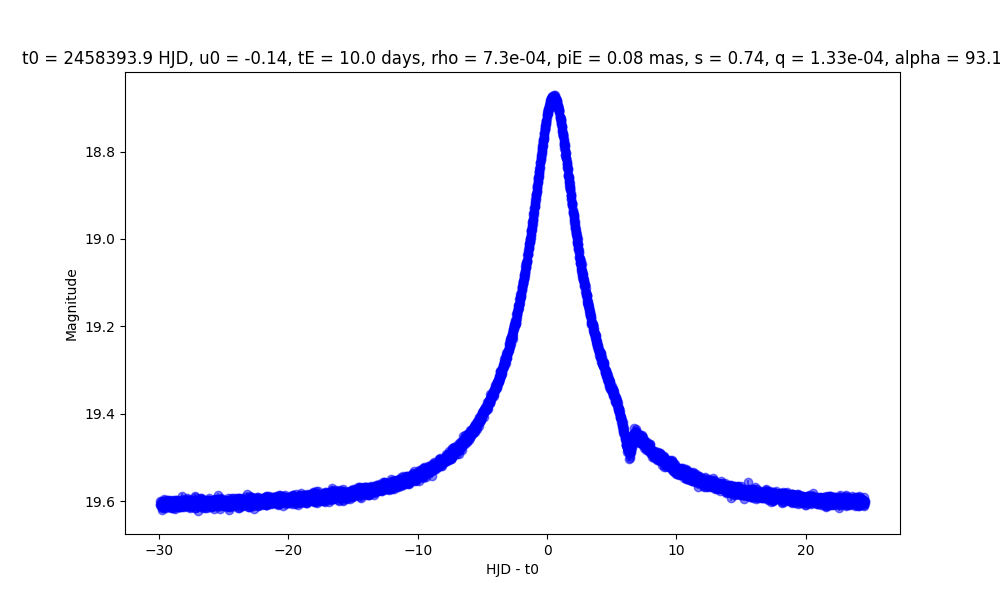

In [165]:
#Plot the light curve
data_bl = pd.read_csv(data_file_bl, sep='\s+', header=None)
data_bl.columns = ['HJD', 'mag', 'err_mag']
data_bl['HJD'] = data_bl['HJD'].astype(float)
data_bl['mag'] = data_bl['mag'].astype(float)
data_bl['err_mag'] = data_bl['err_mag'].astype(float)

#crop data to t_0 - 3*t_E to t_0 + 3*t_E
data_bl = data_bl[(data_bl['HJD'] >= t_0 - 3*t_E) & (data_bl['HJD'] <= t_0 + 3*t_E)]
#Plot the light curve with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(data_bl['HJD'] - t_0, data_bl['mag'], yerr=data_bl['err_mag'], fmt='o', c='blue', alpha=0.5)
plt.xlabel('HJD - t0')
plt.ylabel('Magnitude')
plt.title(f't0 = {t_0:.1f} HJD, u0 = {u_0:.2f}, tE = {t_E:.1f} days, rho = {rho:.1e}, piE = {piE:.2f} mas, s = {s:.2f}, q = {q:.2e}, alpha = {alpha:.1f}')
#invert the y-axis
plt.gca().invert_yaxis()
plt.show()

In [170]:
#save the light curve and params
np.savetxt('dc1_186_W149.txt', data_bl)
params = [t_0, u_0, t_E, rho, piE, s, q, alpha]
np.savetxt('dc1_186_params.txt', params, header='t_0, u_0, t_E, rho, piE, s, q, alpha')



8? 16? 22? 23?? 27 ??
28? 32? 33? 41??
